## 3. Outlier Detection and Processing

We continue from the cleaned dataset produced in the previous checkpoints (redundant columns dropped, nulls handled per-column). Before detecting outliers we quickly redo those steps so this notebook can run standalone.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('house_sale.csv')

# --- carried over from checkpoint 2: drop redundant/plumbing columns ---
cols_to_drop = [
    'total_price', 'repair', 'bill_of_sale', 'mortgage',
    'id_x', 'id_y', 'rel_url', 'estate_rel_url_x', 'estate_rel_url_y', 'estate_rel_url',
    'estate_details_id_x', 'estate_details_id_y', 'currency_y',
    'day_y', 'hour_y', 'datetime_scrape_y', 'updated',
    'currency_x', 'img_url', 'shop_title', 'owner_name', 'owner_title',
    'unit_price', 'Binanın növü',
]
df = df.drop(columns=cols_to_drop)

# --- carried over from checkpoint 2: per-column null handling ---
df['Otaq sayı'] = df['Otaq sayı'].fillna(0)
df['Torpaq sahəsi'] = df['Torpaq sahəsi'].apply(
    lambda x: float(str(x).split(' ')[0]) if pd.notnull(x) else 0.0
)
df['Təmir'] = df['Təmir'].fillna('Naməlum')
df['vip'] = df['vip'].notnull()
df['featured'] = df['featured'].notnull()
df['products_label'] = df['products_label'].fillna('Fərdi')
df['is_agency_listing'] = df['shop_name'].notnull()
df = df.drop(columns=['shop_name'])
df['description'] = df['description'].fillna('')

# parse Sahə (area) into a single numeric m² column, since it mixes 'm²' and 'sot' units
def parse_area(x):
    if pd.isna(x):
        return np.nan
    val_str, unit = str(x).rsplit(' ', 1)
    val = float(val_str)
    return val * 100 if unit == 'sot' else val

df['area_sqm'] = df['Sahə'].apply(parse_area)
df.shape

(100775, 28)

### 3.1 Why price-per-m², not raw price

Raw `price` is a poor outlier signal for real estate: a legitimately large mansion has a high price *because* it's large, not because it's a data error. A better signal is **price per square meter**, since that should sit in a comparable band for similar property types, regardless of how big the property is.

We also restrict the check to residential categories (`Yeni tikili`, `Köhnə tikili`), where price/m² is the natural, comparable unit — land (`Torpaq`) is priced per *sot* on a different scale entirely, so mixing it in would create a meaningless combined distribution.

In [2]:
df['price_per_sqm'] = df['price'] / df['area_sqm']

residential_mask = df['Kateqoriya'].isin(['Yeni tikili', 'Köhnə tikili'])
res = df[residential_mask]
res['price_per_sqm'].describe()

count    7.599600e+04
mean     2.517280e+03
std      1.173942e+04
min      8.111111e-01
25%      2.000000e+03
50%      2.363636e+03
75%      2.814528e+03
max      3.000000e+06
Name: price_per_sqm, dtype: float64

In [3]:
print("Cheapest listings by price/m²:")
print(res.nsmallest(5, 'price_per_sqm')[['price', 'area_sqm', 'price_per_sqm', 'Kateqoriya']])

print("\nMost expensive listings by price/m²:")
print(res.nlargest(5, 'price_per_sqm')[['price', 'area_sqm', 'price_per_sqm', 'Kateqoriya']])

Cheapest listings by price/m²:
       price  area_sqm  price_per_sqm   Kateqoriya
22304   73.0      90.0       0.811111  Yeni tikili
11322  400.0      86.0       4.651163  Yeni tikili
15608  400.0      86.0       4.651163  Yeni tikili
12256  999.0     133.0       7.511278  Yeni tikili
16148  999.0     133.0       7.511278  Yeni tikili

Most expensive listings by price/m²:
             price  area_sqm  price_per_sqm    Kateqoriya
6605   600000000.0     200.0   3.000000e+06   Yeni tikili
6942    60000000.0      50.0   1.200000e+06   Yeni tikili
52783    1750000.0      61.0   2.868852e+04   Yeni tikili
67805    1500000.0      55.0   2.727273e+04  Köhnə tikili
79431     245000.0      10.0   2.450000e+04  Köhnə tikili


These extremes are clear data-entry errors, not real listings — e.g. an apartment priced at 600,000,000 AZN (≈3,000,000 AZN/m²), or one priced at 11 AZN total. Left in, they would badly distort any mean, correlation, or later model.

### 3.2 IQR vs. z-score — which method, and why

We use the **IQR method** rather than z-score for this dataset, because:

- `price_per_sqm` is strongly right-skewed (confirmed by the `describe()` above — mean pulled well above the median), and z-score outlier detection assumes an approximately normal distribution. On skewed data, z-score both under-flags real outliers on the long tail side and can over-flag legitimate values.
- IQR is based on medians and quartiles, so it isn't distorted by the extreme values it's trying to detect in the first place — it's the more robust choice here.

We show a quick skew check before committing to IQR.

In [4]:
print("Skewness of price_per_sqm:", res['price_per_sqm'].skew())
print("Mean:", res['price_per_sqm'].mean().round(1), " Median:", res['price_per_sqm'].median())

Skewness of price_per_sqm: 233.02550751293484
Mean: 2517.3  Median: 2363.6363636363635


A skew this high (heavily right-tailed, mean far above median) confirms IQR is the more appropriate method here.

In [5]:
Q1, Q3 = res['price_per_sqm'].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print(f"IQR bounds: [{low:.0f}, {high:.0f}] AZN/m²")

outlier_mask = (res['price_per_sqm'] < low) | (res['price_per_sqm'] > high)
print(f"Flagged as outliers: {outlier_mask.sum():,} of {len(res):,} residential rows ({outlier_mask.mean()*100:.1f}%)")

IQR bounds: [778, 4036] AZN/m²
Flagged as outliers: 2,335 of 75,996 residential rows (3.1%)


### 3.3 Processing decision: remove, not cap

We **remove** the flagged rows rather than capping/clipping them to the IQR boundary. A price 50-100x too high or too low isn't "an extreme but real value that should be pulled in" — it's almost certainly a typo (e.g. an extra zero, or a per-m² unit price mistakenly entered as the total price). Capping would still leave a fabricated number in the data; since we can't verify the true value for a scraped listing, removing it is the more honest choice.

Non-residential categories (land, offices, garages) are **not** touched here — they were excluded only from this specific price/m² check because they don't share a comparable per-unit basis, not because their prices were reviewed and found clean.

In [6]:
outlier_ids = res.loc[outlier_mask, 'estate_id']
df_clean = df[~df['estate_id'].isin(outlier_ids)].copy()

print(f"Rows before outlier removal: {len(df):,}")
print(f"Rows after outlier removal:  {len(df_clean):,}  ({len(df) - len(df_clean):,} removed)")

Rows before outlier removal: 100,775
Rows after outlier removal:  98,440  (2,335 removed)


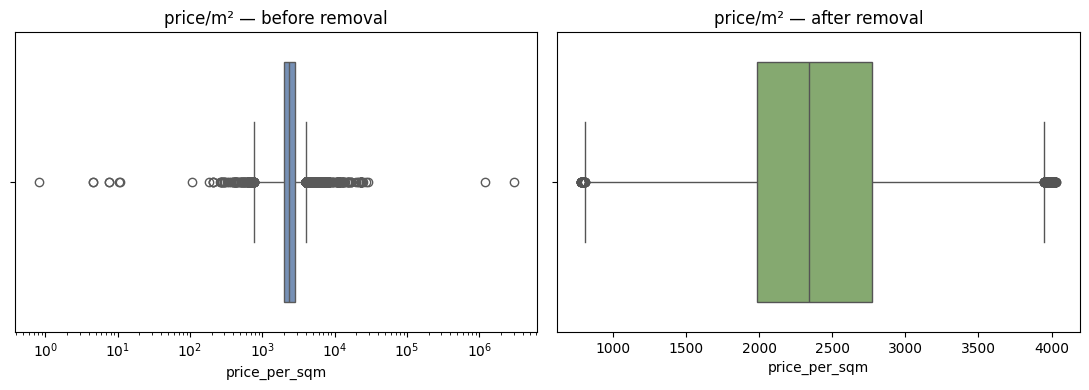

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=res['price_per_sqm'], ax=axes[0], color='#6C8EBF')
axes[0].set_xscale('log')
axes[0].set_title('price/m² — before removal')

sns.boxplot(x=df_clean.loc[df_clean['Kateqoriya'].isin(['Yeni tikili', 'Köhnə tikili']), 'price_per_sqm'],
            ax=axes[1], color='#82B366')
axes[1].set_title('price/m² — after removal')
plt.tight_layout()
plt.show()

**Summary:** outliers were detected using the IQR method on `price_per_sqm` (chosen over z-score due to the strong right skew of the distribution), restricted to residential categories where the metric is comparable, and the ~3% of rows flagged were removed outright rather than capped, since they represent implausible data-entry errors rather than legitimate extreme values.